# Import
Define some function for visualization purpose:

In [ ]:
import numpy as np
import math
import sys
from scipy.special import comb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt

def plot_array_table(array, title="Array Table"):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')  # Hide axes

    # Use .round(2) to format to 2 decimal places
    table = ax.table(
        cellText=array.round(4).values,
        rowLabels=array.index,
        colLabels=array.columns,
        cellLoc='center',
        loc='center'
    )
    table.scale(1.2, 1.5)  # Adjust cell size (col, row)
    ax.set_title(title, fontsize=14)
    plt.show()


In [ ]:
p = 2

# Data Enumeration using Hoang's Conjecture

Recall that the conjecture said:
\begin{equation*}
		(1-\zeta_p)^n = \sum_{j = 0}^{p-2}\sum_{k = 0}^{\lfloor{n/p}\rfloor}\left[{n \ \choose {j+pk}}(-1)^{j+pk} - {n \ \choose {p(k+1) - 1}}(-1)^{p(k+1)-1}\right]\zeta_p^0
\end{equation*}

or
\begin{equation*}
		c_{j,n} = \sum_{k = 0}^{\lfloor{n/p}\rfloor}\left[{n \ \choose {j+pk}}(-1)^{j+pk} - {n \ \choose {p(k+1) - 1}}(-1)^{p(k+1)-1}\right]
\end{equation*}
We now generate data for the coefficients.

In [ ]:
def compute_cjn(j, n, p):
    """
    Compute c_{j,n}
    """
    upperBound = int(np.floor(n/p))
    cjn=0
    for k in range(upperBound + 1):
        cjn += comb(n, j + p*k, exact = True)*pow(-1, j + p*k) - comb(n, p*(k+1) - 1, exact = True)*pow(-1, p*(k+1) - 1)
    return cjn

In [ ]:
import math

def compute_cjn_incremental(j, n, p):
  #Please work...

    upperBound = int(n // p)
    cjn = 0

    # Base: (n 0) to (n j)
    current_comb = 1
    for m in range(j):
        current_comb = current_comb * (n - m) // (m + 1)
    current_idx = j

    for k in range(upperBound + 1):
        idx1 = j + p * k
        idx2 = p * (k + 1) - 1

        for m in range(current_idx, idx1):
            current_comb = current_comb * (n - m) // (m + 1)
        current_idx = idx1
        term1 = current_comb * pow(-1, idx1)

        for m in range(current_idx, idx2):
            current_comb = current_comb * (n - m) // (m + 1)
        current_idx = idx2
        term2 = current_comb * pow(-1, idx2)

        cjn += term1 - term2

    return cjn

In [ ]:
def decompose_n(n, p):
    """
    Given n and p, find a and m such that:
    n = a + p*(p-1)*m, with 0 <= a <= p*(p-1) - 1
    """
    a = n % (p * (p - 1))
    m = (n - a) // (p * (p - 1))
    return a, m

def generate_table(n_values, p):
    """
    Generate DataFrame with columns:
    n, a, m, c_0n, c_1n, ..., c_(p-2)n
    """
    data = []
    for n in n_values:
        a, m = decompose_n(n, p)
        row = [n, a, m]
        for j in range(p - 1):
            row.append(compute_cjn(j, n, p))
        data.append(row)

    columns = ['n', 'a', 'm'] + [f'c_{j}n' for j in range(p - 1)]
    df = pd.DataFrame(data, columns=columns)
    return df

n_values = range(0, 2*p*(p-1)+1)
coefficients_data = generate_table(n_values, p)
coefficients_data


,n,a,m,c_0n
0,0,0,0,1
1,1,1,0,2
2,2,0,1,4
3,3,1,1,8
4,4,0,2,16


# Prime Factorization Algorithm
We want to pull out from the coefficients the power of $p$. Since we already have a general enumarative method for the coefficients, we first implement a prime factorization algorithm. This, however, can goes to a generatively small $n$ depending on how strong the computer are.

In [ ]:
def prime_factors(n):
    """
    Return prime factors of integer n as a dict {prime: exponent}.
    Handles negative numbers by factoring out -1.
    """
    factors = {}

    # Handle negative numbers
    if n < 0:
        factors[-1] = 1
        n = -n

    if n == 0:
        return {0: 1}  # Special case: 0 has no prime factorization

    # Factor out 2's
    while n % 2 == 0 and n > 0:
        factors[2] = factors.get(2, 0) + 1
        n //= 2

    # Check odd factors
    p = 3
    while p * p <= n:
        while n % p == 0:
            factors[p] = factors.get(p, 0) + 1
            n //= p
        p += 2

    # If n is still > 1, it is prime
    if n > 1:
        factors[n] = factors.get(n, 0) + 1

    return factors

def format_factorization(factors):
    """
    Format factors dict into a string: e.g. {2: 3, 3: 1} -> "2^3*3^1"
    """
    return '*'.join(f"({p}^{e})" for p, e in sorted(factors.items()))

def factorize_dataframe(df):
    """
    Given the coefficients DataFrame, return a new DataFrame
    where coefficient columns are replaced by their prime factorization strings.
    Automatically detects coefficient columns.
    """
    # Identify coefficient columns dynamically
    coef_cols = [col for col in df.columns if col not in ['n', 'a', 'm']]

    fact_df = df.copy()
    for col in coef_cols:
        fact_df[col] = fact_df[col].apply(
            lambda x: format_factorization(prime_factors(x))
        )
    return fact_df


fact_df = factorize_dataframe(coefficients_data)
print("\nPrime factorizations:")
fact_df


Prime factorizations:


,n,a,m,c_0n
0,0,0,0,
1,1,1,0,(2^1)
2,2,0,1,(2^2)
3,3,1,1,(2^3)
4,4,0,2,(2^4)


# A trig formula for $c_{j,n}$
We continue to conject that
\begin{equation}
c_{j,n} = \dfrac{1}{p}2^{n+2}\left[\sum_{k=1}^{(p-1)/2}\sin{\left(\dfrac{k\pi}{p}(p-1-j)\right)}\sin^{n}{\left(-\dfrac{k\pi}{p}\right)}\cos{\left(\dfrac{-2\pi k(p-1+j)+p\pi}{2p} + n\dfrac{\pi(2k+p)}{2p}\right)}\right]
\end{equation}

In [ ]:
def compute_cjn_trig(j,n,p):
  upperBound = (p-1)/2
  cjn_trig = 0
  for k in range(1, int(upperBound) + 1):
    print("COMPUTE TRIG FORM: J, N, P, K=", j, n, p, k)
    # Term 1: sin( (k*pi/p) * (p-1-j) )
    arg1 = (k*np.pi/p)*(p-1-j)
    term1 = np.sin(arg1)

    # Term 2: sin^n( -k*pi/p )
    arg2 = -(k*np.pi/p)
    term2 = pow(np.sin(arg2),n)

    # Term 3: cos( (-2pk(p-1+j)+p*pi)/(2p) + n*pi(2k+p)/(2p) )
    cos_arg = (-2*np.pi*k*(p-1+j)+p*np.pi)/(2*p)+(n*np.pi*(2*k+p))/(2*p)
    term3 = np.cos(cos_arg)
    cjn_trig += term1 * term2 * term3
  cjn_trig = cjn_trig*(1/p)*pow(2,n+2)

  return cjn_trig


In [ ]:
notMatchCases = []
precision = 1
totalCase = 0
notMatchCasesCount = 0

p = 3
for n in range(100):
  for j in range(p-1):
    print("N=", n, "j=", j)
    cjn_trig = compute_cjn_trig(j,n,p)
    cjn = compute_cjn(j,n,p)
    print("Printing cjn..............", cjn.real)
    print("Printing cjn_trig..............", cjn_trig)
    print("Difference..............", abs(cjn.real - cjn_trig))
    match = abs(cjn.real - cjn_trig) < precision
    if not match:
      notMatchCases.append((n,j))
      notMatchCasesCount += 1
    print("Equal?....................", match, "\n")
    totalCase +=1
print("There are", notMatchCasesCount, "/", totalCase, "cases that does not match.")
print("Cases not match", notMatchCases)


N= 0 j= 0
COMPUTE TRIG FORM: J, N, P, K= 0 0 3 1
Printing cjn.............. 1
Printing cjn_trig.............. 1.0
Difference.............. 0.0
Equal?.................... True 

N= 0 j= 1
COMPUTE TRIG FORM: J, N, P, K= 1 0 3 1
Printing cjn.............. 0
Printing cjn_trig.............. 7.070501591499378e-17
Difference.............. 7.070501591499378e-17
Equal?.................... True 

N= 1 j= 0
COMPUTE TRIG FORM: J, N, P, K= 0 1 3 1
Printing cjn.............. 1
Printing cjn_trig.............. 1.0000000000000004
Difference.............. 4.440892098500626e-16
Equal?.................... True 

N= 1 j= 1
COMPUTE TRIG FORM: J, N, P, K= 1 1 3 1
Printing cjn.............. -1
Printing cjn_trig.............. -0.9999999999999997
Difference.............. 3.3306690738754696e-16
Equal?.................... True 

N= 2 j= 0
COMPUTE TRIG FORM: J, N, P, K= 0 2 3 1
Printing cjn.............. 0
Printing cjn_trig.............. -6.363451432349439e-16
Difference.............. 6.363451432349439e-16
Equal?.

# HOLD: NOV. 20 -- IT SEEMS LIKE SOMETHING IS OFF
This is the code to verify that I was not wrong.

In [ ]:

cjn_trig = 0
for p in range (1,1000):
  upperBound = (p-1)/2
  for k in range(1, int(upperBound) + 1):
    # Term 1: sin( (k*pi/p) * (p-1-j) )
    arg1 = (k*np.pi/p)*(p-1-j)
    term1 = np.sin(arg1)

    # Term 2: sin^n( -k*pi/p )
    arg2 = -(k*np.pi/p)
    term2 = pow(np.sin(arg2),n)

    # Term 3: cos( (-2pk(p-1+j)+p*pi)/(2p) + n*pi(2k+p)/(2p) )
    cos_arg = (-2*np.pi*k*(p-1+j)+p*np.pi)/(2*p)+(n*np.pi*(2*k+p))/(2*p)
    term3 = np.cos(cos_arg)
    cjn_trig += term1 * term2 * term3
    print(cjn_trig)
    print(upperBound)


Streaming output truncated to the last 5000 lines.
0.4387612643286155
496.5
0.43800122093065247
496.5
0.42053061297363564
496.5
0.391345997958406
496.5
0.35619394460378895
496.5
0.3206821717937577
496.5
0.28947073664923306
496.5
0.2656553389549625
496.5
0.2504249093162334
496.5
0.2430347090852781
496.5
0.24108995459132487
496.5
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487
497.0
0.24108995459132487


Conclusion: I was right.

# Big O Analysis
This section contains code to do Big O analysis for the recursion, combinatorial, and trig approach.

In [ ]:
def c0_recursive(n):
    if n == 0:
        return 1
    # Calls both functions for n-1
    return c0_recursive(n - 1) + c1_recursive(n - 1)

def c1_recursive(n):
    if n == 0:
        return 0
    # Calls both functions for n-1 again
    return 2 * c1_recursive(n - 1) - c0_recursive(n - 1)

def f1(j, n, p=3):
    """Wrapper function to match your benchmarking script format."""
    if p != 3:
        raise NotImplementedError("This naive recursive example is only defined for p=3")
    return c0_recursive(n), c1_recursive(n)

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_10735/3530864848.py:34: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(n_values_small, time_f3_small, label='Approach 3 (Trigonometric): $O(\log n)$', color='green', marker='^')


COMPUTE TRIG FORM: J, N, P, K= 0 1 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 2 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 3 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 4 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 5 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 6 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 7 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 8 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 9 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 10 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 11 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 12 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 13 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 14 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 15 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 16 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 17 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 18 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 19 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 20 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 21 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 22 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 23 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 24 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 25 3 1


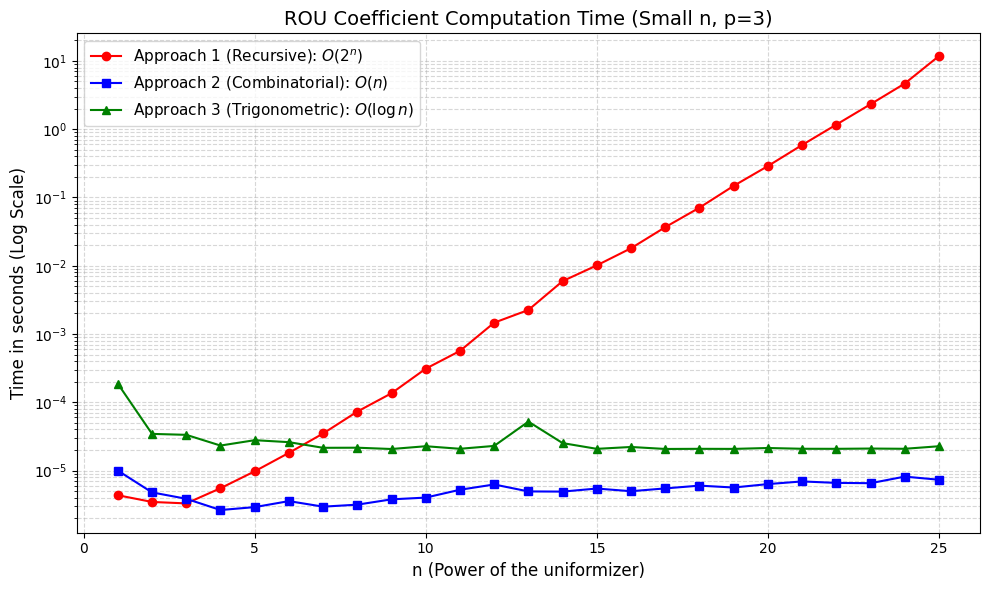

In [ ]:
import time
import matplotlib.pyplot as plt

# Assuming your three functions f1(n, p), f2(n, p), and f3(n, p)
# are defined above this script in your actual file.

# Fix the prime p for the experiment (e.g., p = 5 as referenced in your study)
P = 3

def benchmark_function(func, j, n_values, p):
    """Runs a given function over a list of n values and returns the execution times."""
    execution_times = []
    for n in n_values:
        start_time = time.perf_counter()
        func(j, n, p)
        end_time = time.perf_counter()
        execution_times.append(end_time - start_time)
    return execution_times

# =====================================================================
# Figure 1: The Small Scale (Comparing f1, f2, f3 with a Logarithmic Y-Axis)
# =====================================================================

# Keep n small here so f1 doesn't cause a recursion depth error or freeze your machine
n_values_small = list(range(1, 26))

time_f1 = benchmark_function(f1, 0, n_values_small, P)
time_f2_small = benchmark_function(compute_cjn_incremental, 0, n_values_small, P)
time_f3_small = benchmark_function(compute_cjn_trig, 0, n_values_small, P)

plt.figure(figsize=(10, 6))
plt.plot(n_values_small, time_f1, label='Approach 1 (Recursive): $O(2^n)$', color='red', marker='o')
plt.plot(n_values_small, time_f2_small, label='Approach 2 (Combinatorial): $O(n)$', color='blue', marker='s')
plt.plot(n_values_small, time_f3_small, label='Approach 3 (Trigonometric): $O(\log n)$', color='green', marker='^')

# Using a log scale for the Y-axis prevents the recursive function from flattening the other two lines
plt.yscale('log')
plt.title(f'ROU Coefficient Computation Time (Small n, p={P})', fontsize=14)
plt.xlabel('n (Power of the uniformizer)', fontsize=12)
plt.ylabel('Time in seconds (Log Scale)', fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()



In [ ]:
# Export Figure 1 Data (Small n, p=3)
df1 = pd.DataFrame({
    'n': n_values_small,
    'time_recursive': time_f1,
    'time_combinatorial': time_f2_small,
    'time_trig': time_f3_small
})
df1.to_csv('fig1_data.csv', index=False)
df1

,n,time_recursive,time_combinatorial,time_trig
0,1,0.000003,0.000070,0.000182
1,2,0.000003,0.000008,0.000029
2,3,0.000003,0.000005,0.000022
3,4,0.000005,0.000004,0.000019
4,5,0.000008,0.000004,0.000020
5,6,0.000016,0.000005,0.000020
6,7,0.000032,0.000005,0.000018
7,8,0.000063,0.000004,0.000019
8,9,0.000126,0.000005,0.000018
9,10,0.000751,0.000006,0.000019


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df1)

https://docs.google.com/spreadsheets/d/1jb1Ts8MK8tpwmEMh5dMBj7TgbnEie-aNcn29nDyTfKw/edit#gid=0


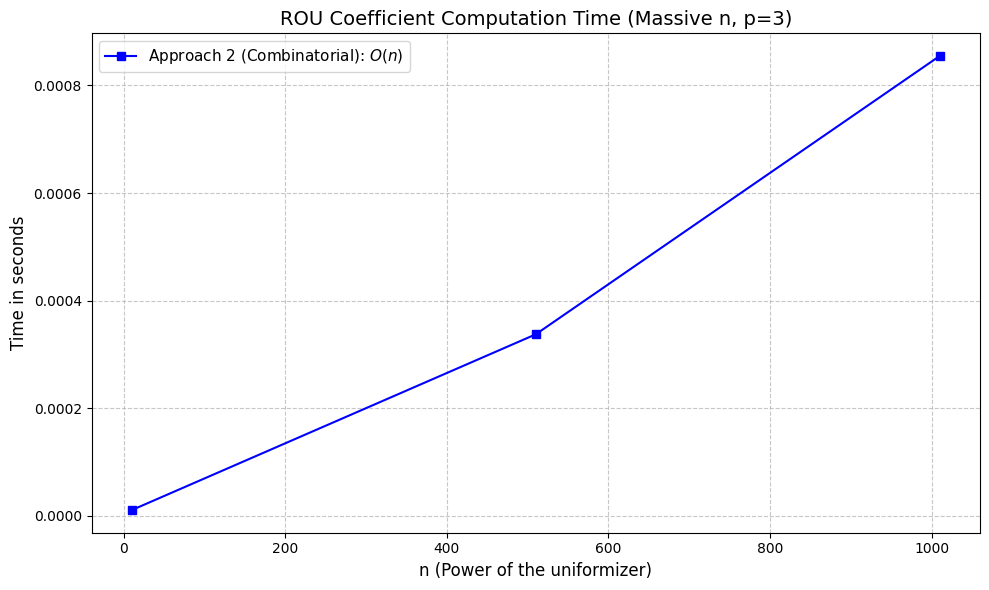

In [ ]:
# =====================================================================
# Figure 2: The Massive Scale (Comparing f2 and f3 with a Linear Y-Axis)
# =====================================================================

# Generate a list from n=10 to n=1510, stepping by 500
n_values_large = list(range(10, 1500, 500))

# We drop f1 entirely here because computing it for n=10000 is impossible
time_f2_large = benchmark_function(compute_cjn_incremental, 0, n_values_large, P)
#time_f3_large = benchmark_function(compute_cjn_trig, 0, n_values_large, P)

plt.figure(figsize=(10, 6))
plt.plot(n_values_large, time_f2_large, label='Approach 2 (Combinatorial): $O(n)$', color='blue', marker='s')
#plt.plot(n_values_large, time_f3_large, label='Approach 3 (Trigonometric): $O(\log n)$', color='green', marker='^')

# Standard linear scale to show the true difference between O(n) and O(log n)
plt.title(f'ROU Coefficient Computation Time (Massive n, p={P})', fontsize=14)
plt.xlabel('n (Power of the uniformizer)', fontsize=12)
plt.ylabel('Time in seconds', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
df2 = pd.DataFrame({
    'n': n_values_large,
    'time_combinatorial': time_f2_large,
    'time_trig': time_f3_large
})
df2.fillna('', inplace=True)
df2.to_csv('fig2_data.csv', index=False)
df2

,n,time_combinatorial,time_trig
0,10,0.000082,0.000246
1,510,0.010012,0.000033
2,1010,0.056092,0.000025


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df2)

https://docs.google.com/spreadsheets/d/1zWTu66WcQU_B8BBkYg-q-owwEjA_qIrNhv3b2iYrOig/edit#gid=0


COMPUTE TRIG FORM: J, N, P, K= 0 10 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 10 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 110 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 110 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 210 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 210 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 310 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 310 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 410 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 410 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 510 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 510 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 610 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 610 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 710 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 710 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 810 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 810 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 910 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 910 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 1010 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 1010 5 2
COMPUTE TRIG FORM: J, N, P, K= 0 1110 5 1
COMPUTE TRIG FORM: J, N, P, K= 0 1110 5 2


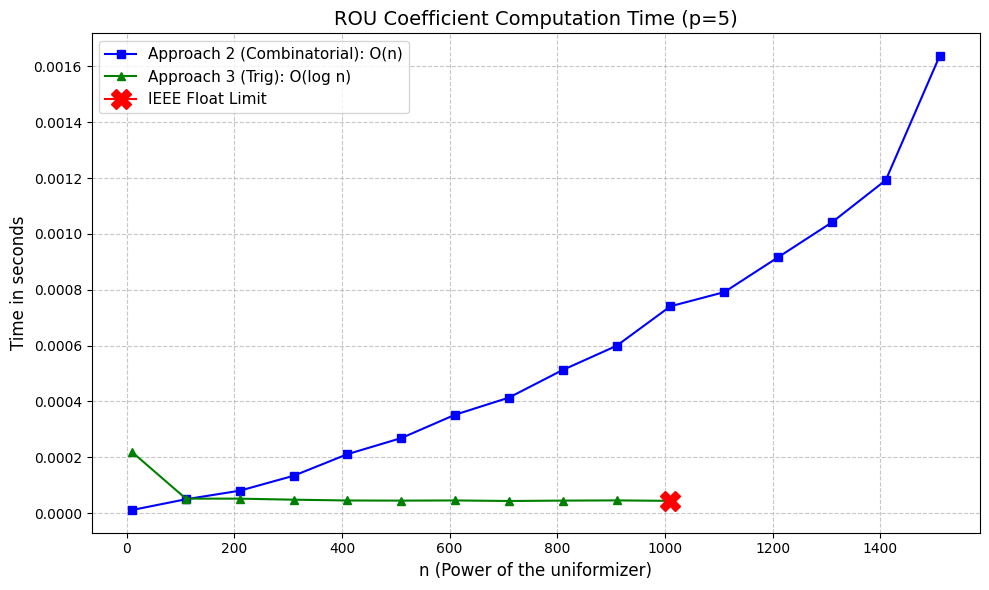

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np

def benchmark_with_limits(func, j, n_values, p):
    execution_times = []
    last_success_n = None
    last_success_time = None
    crashed = False

    for n in n_values:
        if crashed:
            execution_times.append(None)
            continue

        try:
            start_time = time.perf_counter()
            func(j, n, p)
            end_time = time.perf_counter()

            elapsed = end_time - start_time
            execution_times.append(elapsed)

            last_success_n = n
            last_success_time = elapsed

        except OverflowError:
            crashed = True
            execution_times.append(None)

    return execution_times, last_success_n, last_success_time

# We step by 100 to get a smooth line before the crash happens
n_values_large = list(range(10, 1511, 100))
P = 5
J = 0

# Run the benchmarks
time_f2_large, _, _ = benchmark_with_limits(compute_cjn_incremental, J, n_values_large, P)
time_f3_large, trig_fail_n, trig_fail_time = benchmark_with_limits(compute_cjn_trig, J, n_values_large, P)

plt.figure(figsize=(10, 6))

# Plot Combinatorial (will survive the whole way)
plt.plot(n_values_large, time_f2_large, label='Approach 2 (Combinatorial): O(n)', color='blue', marker='s')

# Plot Trigonometric (will break midway)
plt.plot(n_values_large, time_f3_large, label='Approach 3 (Trig): O(log n)', color='green', marker='^')

# If the trig function failed, plot a big red X where it gave up and annotate it
if trig_fail_n is not None and trig_fail_n < max(n_values_large):
    plt.plot(trig_fail_n, trig_fail_time, marker='X', color='red', markersize=14, label='IEEE Float Limit')

    # Add an arrow and text pointing to the crash site


plt.title(f'ROU Coefficient Computation Time (p={P})', fontsize=14)
plt.xlabel('n (Power of the uniformizer)', fontsize=12)
plt.ylabel('Time in seconds', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1011/2938650222.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(n_values_large, time_f3_large, label='Approach 3 (Trigonometric): $O(\log n)$', color='green', marker='^')


COMPUTE TRIG FORM: J, N, P, K= 0 10 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 20 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 30 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 40 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 50 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 60 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 70 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 80 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 90 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 100 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 110 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 120 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 130 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 140 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 150 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 160 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 170 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 180 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 190 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 200 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 210 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 220 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 230 3 1
COMPUTE TRIG FORM: J, N, P, K= 0 240 3 1
COMPUTE TRIG FORM: J, N, 

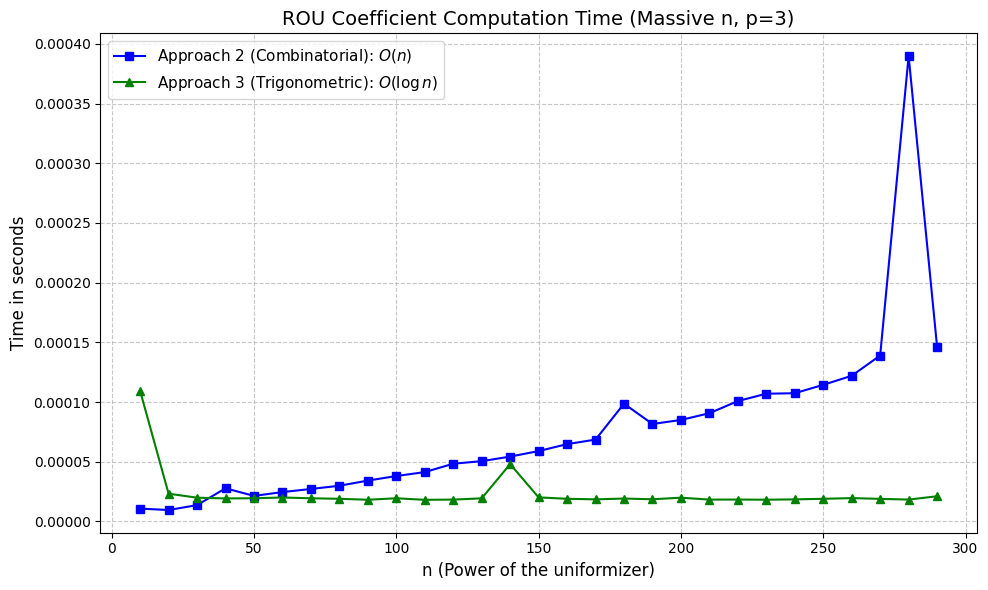

In [ ]:
# =====================================================================
# Figure 2: The Massive Scale (Comparing f2 and f3 with a Linear Y-Axis)
# =====================================================================

# Generate a list from n=10 to n=1510, stepping by 500
n_values_large = list(range(10, 300, 10))

# We drop f1 entirely here because computing it for n=10000 is impossible
time_f2_large = benchmark_function(compute_cjn_incremental, 0, n_values_large, P)
time_f3_large = benchmark_function(compute_cjn_trig, 0, n_values_large, P)

plt.figure(figsize=(10, 6))
plt.plot(n_values_large, time_f2_large, label='Approach 2 (Combinatorial): $O(n)$', color='blue', marker='s')
plt.plot(n_values_large, time_f3_large, label='Approach 3 (Trigonometric): $O(\log n)$', color='green', marker='^')

# Standard linear scale to show the true difference between O(n) and O(log n)
plt.title(f'ROU Coefficient Computation Time (Massive n, p={P})', fontsize=14)
plt.xlabel('n (Power of the uniformizer)', fontsize=12)
plt.ylabel('Time in seconds', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()